# Occupancy Maps & Path Planning

**Objective:** In this notebook, we will learn the fundamental pipeline of path planning:
1.  **Map Processing:** Loading a map image and converting it into an **Occupancy Grid**.
2.  **Configuration Space:** Inflating obstacles to account for the robot's size.
3.  **Global Planning:** Finding a path from Start to Goal using planning algorithms.

In [1]:
# Installation prerrequisites
!pip install python-motion-planning==2.0.dev2

In [2]:
# Importing necessary libraries
import json
import numpy as np
import imageio.v3 as iio
from python_motion_planning.common import *
from python_motion_planning.path_planner import *
from python_motion_planning.controller import *

## 1. Loading the Map

Robots usually use **Occupancy Grid Maps**. These are essentially discretized grids where each cell represents a specific area in the world.
* **Image:** A grayscale image where dark pixels are obstacles and light pixels are free space.
* **Metadata:** Contains the real-world resolution (meters per pixel) and origin coordinates.

In [3]:
# 1. Load map metadata
with open("occupancy_map.json", "r") as f:
    meta = json.load(f)

image_path = meta["image"]
resolution = meta["resolution"]
origin = meta["origin"]

# 2. Load occupancy image
img = iio.imread(image_path)
if img.ndim == 3:
    img = np.mean(img, axis=2)
img = np.rot90(img, k=3) # Coordinate adjustment
height, width = img.shape

## 2. Creating the Grid & Obstacles

We interpret the image pixel intensities. We threshold the image to define what is an obstacle and what is free.

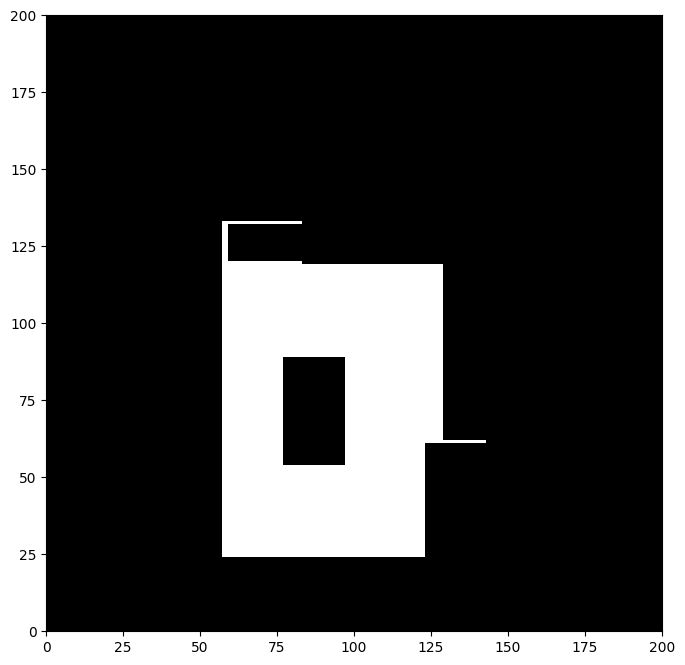

In [4]:
# 3. Create an empty Grid map object
map_ = Grid(bounds=[[0, width], [0, height]])

# 4. define Thresholds
# Pixels darker than 128 are considered obstacles
obstacle_mask = img < 128
free_mask = img >= 128

# Apply these masks to our Grid object
map_.type_map[:, :] = TYPES.FREE
map_.type_map[obstacle_mask] = TYPES.OBSTACLE

vis = Visualizer2D("Occupancy Map (Inflated)")
vis.plot_grid_map(map_)
vis.show()
vis.close()

## 3. Obstacle Inflation (Configuration Space)

A robot is not a single point; it has a physical radius. If we plan a path right next to a wall for a point, a real robot will crash into the wall.

To solve this, we transform the map into **Configuration Space (C-Space)**. We "inflate" the obstacles by the radius of the robot.

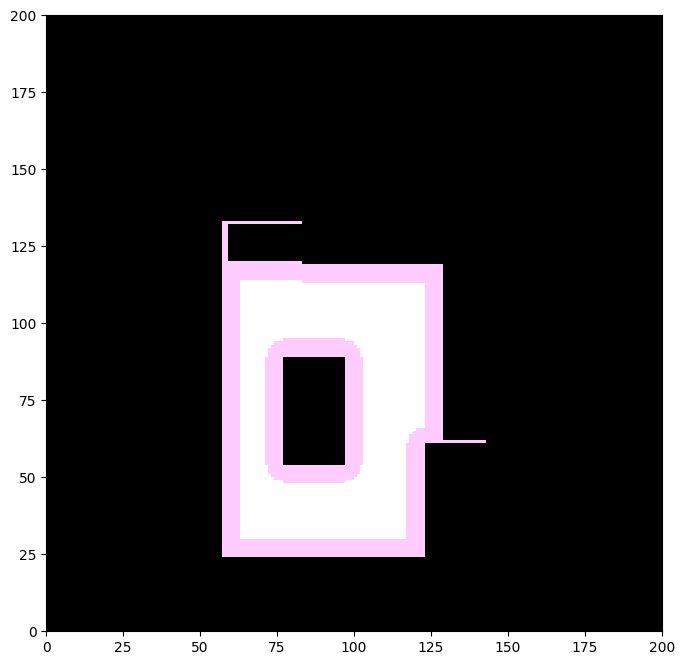

In [5]:
# 5. Inflate obstacles
inflate_radius_m = 0.3  # The safety radius in meters (TIAGo's diameter is 54cm)

# Convert meters to pixels based on map resolution
inflate_radius_px = int(np.ceil(inflate_radius_m / resolution))
map_.inflate_obstacles(radius=inflate_radius_px)

vis2 = Visualizer2D("Occupancy Map (Inflated)")
vis2.plot_grid_map(map_)
vis2.show()
vis2.close()

## 4. Path Planning: Graph Search (Dijkstra)

We will use **Dijkstra's Algorithm** to find the optimal path. It explores the grid in waves (expanding nodes) to guarantee the shortest path.

* **Gray areas:** These are "Expanded Nodes" (places the algorithm looked at).
* **Line:** The resulting optimal path.

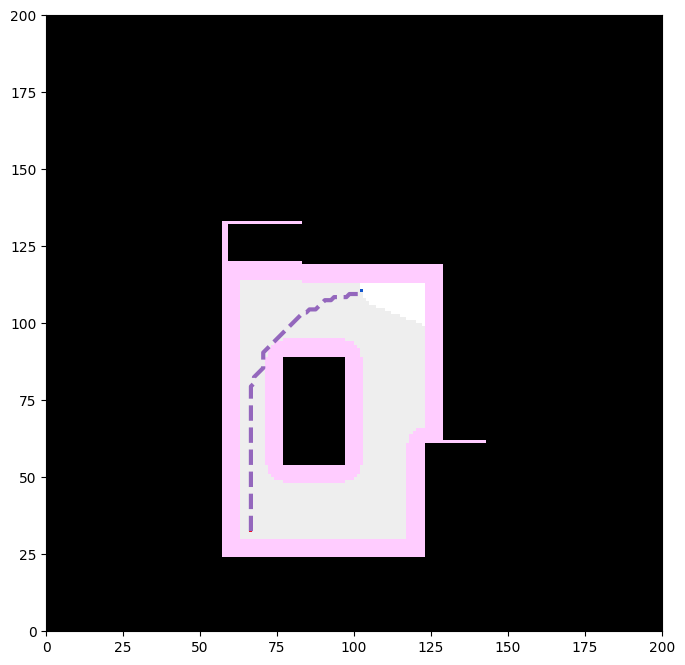

In [6]:
# Define Start and Goal coordinates (in grid pixels)
start = (66, 32)
goal = (102, 110)

# Mark them on the map for visualization
map_.type_map[start] = TYPES.START
map_.type_map[goal] = TYPES.GOAL

# Initialize the Planner and run it
planner = Dijkstra(map_=map_, start=start, goal=goal)
path, path_info = planner.plan()

# Save the expansion info to visualize how the algorithm 'searched'
map_.fill_expands(path_info["expand"])

# Visualize the result
vis3 = Visualizer2D("Dijkstra Path Planning")
vis3.plot_grid_map(map_)
vis3.plot_path(path, style="--", color="C4")
vis3.show()
vis3.close()

## 5. Alternative: Sample-based Planning (RRT*)

Unlike Dijkstra, which checks every grid neighbor, **RRT (Rapidly-exploring Random Trees)** samples random points in space and tries to connect them.

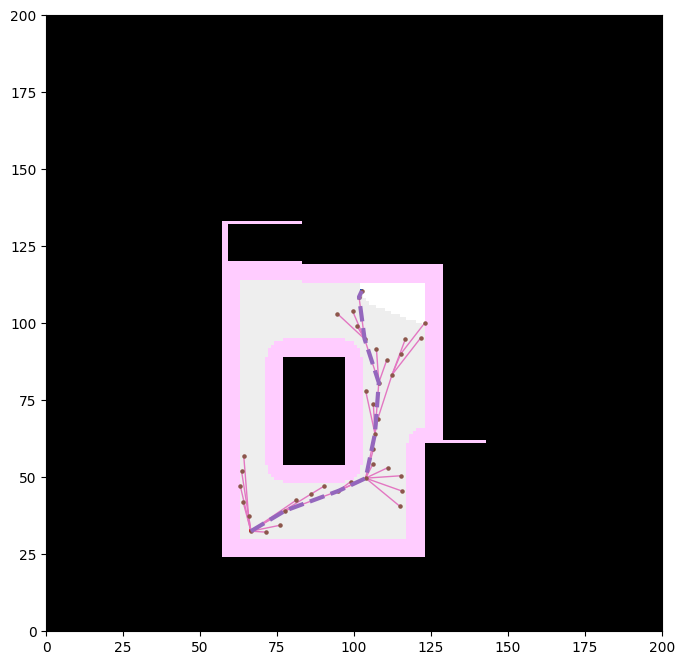

In [7]:
# Define Start and Goal coordinates (in grid pixels)
start = (66, 32)
goal = (102, 110)

# Mark them on the map for visualization
map_.type_map[start] = TYPES.START
map_.type_map[goal] = TYPES.GOAL

# Initialize the planner and run it
planner_rrt = RRTStar(map_=map_, start=start, goal=goal)
path, path_info_rrt = planner_rrt.plan()

vis4 = Visualizer2D("RRT* Path Planning")
vis4.plot_grid_map(map_)
vis4.plot_path(path, style="--", color="C4")

# Visualize the tree of random samples
vis4.plot_expand_tree(path_info_rrt["expand"])
vis4.show()
vis4.close()